In [59]:
import pandas as pd 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from feature_engine.selection import DropConstantFeatures
from src.data.features import MutualInfoSelector

from src.data.loading import loading, sample 
from src.data.cleaning import cleaning 
from src.data.splitting import cross_val_split


raw_df = loading(file_path='/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/accepted_2007_to_2018Q4.csv')
raw_sample = sample(df=raw_df)
cleaned_sample = cleaning(df=raw_sample)


Reading and loading file ...


/Users/thananpornsethjinda/Desktop/credit-risk-modeling/src/data/loading.py:12: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv(file_path)


Data successfully read in 28.433934688568115 seconds!
Starting data cleaning
Grouping target variable to binary targets (Charged Off) and (Fully Paid) ...
Dropping loan status null values
A total of 45 were dropped; with the columns being ['member_id', 'desc', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_rcnt_il', 'il_util', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date'

In [81]:
raw_df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
X_train_val, X_test, y_train_val, y_test = cross_val_split(df=cleaned_sample)

from sklearn import set_config

# This forces all transformers to output DataFrames instead of Numpy arrays
set_config(transform_output="pandas")

NUMERICAL_FEATURES = X_train_val.select_dtypes(include=['float64']).columns

ONE_HOT_FEATURES = ['term', 'home_ownership']

ORDINAL_FEATURES = ['sub_grade']

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaling", RobustScaler())
    ]
)

CATEGORICAL_FEATURES = [
    col for col in X_train_val.select_dtypes(exclude=['float64']).columns 
    if col not in ONE_HOT_FEATURES and col not in ORDINAL_FEATURES
]

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

one_hot_transformer = Pipeline(
    steps=[
        ("one-hot-encoding", OneHotEncoder(drop="first", sparse_output=False))
    ]
)


ordinal_transformer = Pipeline(
    steps=[
        ("ordinal-encoding", OrdinalEncoder())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, NUMERICAL_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
        ("cat_one_hot", one_hot_transformer, ONE_HOT_FEATURES),
        ("cat_ordinal", ordinal_transformer, ORDINAL_FEATURES)
    ]
)

In [12]:
pipeline.named_steps['mutual-information selector'].get_feature_names_out()

array(['num__funded_amnt', 'num__int_rate', 'num__installment',
       'num__dti', 'num__fico_range_low', 'num__open_acc_6m',
       'num__open_rv_12m', 'num__inq_last_12m',
       'num__acc_open_past_24mths', 'num__bc_open_to_buy',
       'num__mort_acc', 'num__num_actv_rev_tl', 'num__num_tl_op_past_12m',
       'cat_one_hot__term_ 60 months', 'cat_ordinal__sub_grade'],
      dtype=object)

In [6]:
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor), 
        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95))
    ]
)

pipeline.fit(X_train_val, y_train_val)

feature_names_out = pipeline.get_feature_names_out()

categorical_indices = []
for idx, feature_name in enumerate(feature_names_out):
    # Features from one-hot transformer will have prefix 'cat_one_hot__'
    # Features from ordinal transformer will have prefix 'cat_ordinal__'
    if feature_name.startswith('cat_one_hot__') or feature_name.startswith('cat_ordinal__'):
        print(feature_name)
        categorical_indices.append(idx)

print(f"Categorical indices: {categorical_indices}")
print(f"Total features after preprocessing: {len(feature_names_out)}")

cat_one_hot__term_ 60 months
cat_one_hot__home_ownership_MORTGAGE
cat_one_hot__home_ownership_OWN
cat_one_hot__home_ownership_RENT
cat_ordinal__sub_grade
Categorical indices: [45, 46, 47, 48, 49]
Total features after preprocessing: 50


## Hyperparameter Fine Tuning

In [14]:
from sklearn.linear_model import LogisticRegression

In [29]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor), 
        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
        ("mutual-information selector", MutualInfoSelector(k=15, categorical_indices=[45, 46, 47, 48, 49])), 
        ("lr", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [32]:
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer

f1 = make_scorer(f1_score, average='weighted')
precision = make_scorer(precision_score, pos_label=1)
recall = make_scorer(recall_score, pos_label=1)
scoring = {'f1': f1, 'precision':precision, 'recall':recall}


In [33]:
y_train_numeric = y_train_val.map({'Fully Paid': 0, 'Charged Off': 1})
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(lr_pipeline, X_train_val, y_train_numeric, cv=cv, scoring=scoring, n_jobs=-1)


/Users/thananpornsethjinda/Library/Caches/pypoetry/virtualenvs/credit-risk-RG99JJ23-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor), 
        ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
        ("mutual-information selector", MutualInfoSelector(k=15, categorical_indices=[45, 46, 47, 48, 49])), 
        ("dc", DecisionTreeClassifier())
    ]
)

y_train_numeric = y_train_val.map({'Fully Paid': 0, 'Charged Off': 1})
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(decision_tree_pipeline, X_train_val, y_train_numeric, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)

In [64]:
scores

{'fit_time': array([87.11465502, 86.28607416, 87.08151579, 88.06589103, 87.41255808]),
 'score_time': array([0.13802791, 1.23264313, 0.20798993, 0.39933395, 0.30111098]),
 'test_f1': array([0.69079528, 0.69445028, 0.69370818, 0.6957981 , 0.69207815]),
 'train_f1': array([0.99990883, 1.        , 1.        , 1.        , 1.        ]),
 'test_precision': array([0.28733032, 0.29617505, 0.2922423 , 0.29662522, 0.29182347]),
 'train_precision': array([1., 1., 1., 1., 1.]),
 'test_recall': array([0.31156822, 0.32440083, 0.31132075, 0.31509434, 0.32188679]),
 'train_recall': array([0.99957545, 1.        , 1.        , 1.        , 1.        ])}

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = cross_val_predict(decision_tree_pipeline, X_train_val, y_train_numeric, cv=cv, n_jobs=-1)
cm = confusion_matrix(y_train_numeric, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

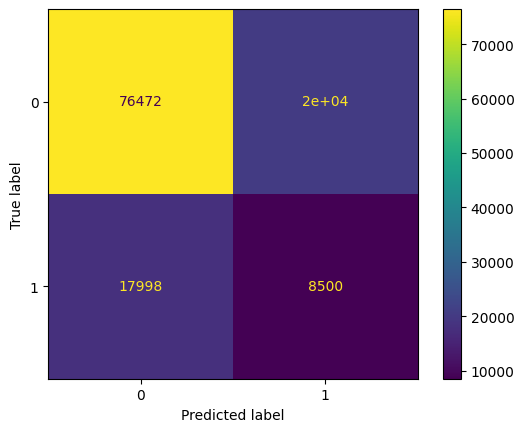

In [66]:
disp.plot()

In [74]:
from sklearn.metrics import fbeta_score

def train(pipeline): 

    f1 = make_scorer(f1_score, average='weighted')
    precision = make_scorer(precision_score, pos_label=1)
    recall = make_scorer(recall_score, pos_label=1)
    f2 = make_scorer(fbeta_score, average='weighted', beta=2)
    scoring = {'f1': f1, 'precision':precision, 'recall':recall, 'f2': f2}

    y_train_numeric = y_train_val.map({'Fully Paid': 0, 'Charged Off': 1})
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipeline, X_train_val, y_train_numeric, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)

    print(pd.DataFrame(scores).mean())

    y_pred = cross_val_predict(pipeline, X_train_val, y_train_numeric, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y_train_numeric, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()

## Decision Tree 

fit_time           32.036316
score_time          0.151895
test_f1             0.690936
train_f1            1.000000
test_precision      0.288489
train_precision     1.000000
test_recall         0.315382
train_recall        1.000000
test_f2             0.687898
train_f2            1.000000
dtype: float64


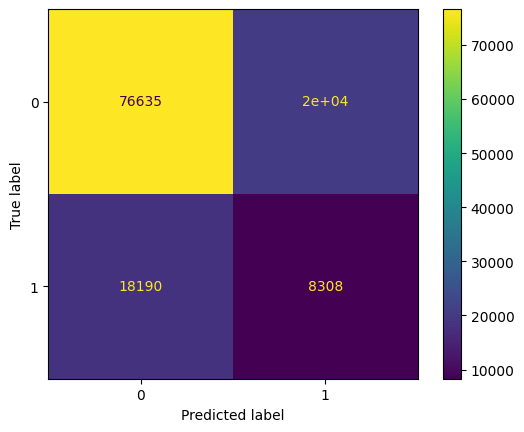

In [75]:
model = DecisionTreeClassifier()

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=15, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", model)
        ]
    )

train(pipeline)

fit_time           33.354886
score_time          0.120381
test_f1             0.690809
train_f1            0.693640
test_precision      0.338273
train_precision     0.342415
test_recall         0.581101
train_recall        0.588073
test_f2             0.671238
train_f2            0.674180
dtype: float64


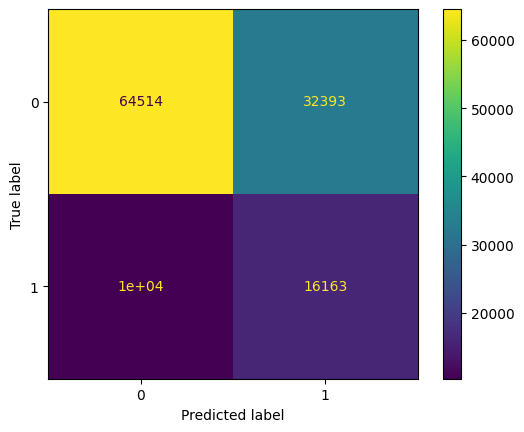

In [77]:
model = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth (start with 5-10)
    min_samples_split=100,    # Need at least 100 samples to split a node
    min_samples_leaf=50,      # Each leaf must have at least 50 samples
    max_features='sqrt',      # Only consider sqrt(n_features) at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=15, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", model)
        ]
    )

train(pipeline)

fit_time           33.854875
score_time          0.146685
test_f1             0.663165
train_f1            0.664494
test_precision      0.325471
train_precision     0.327689
test_recall         0.647631
train_recall        0.652106
test_f2             0.636824
train_f2            0.638187
dtype: float64


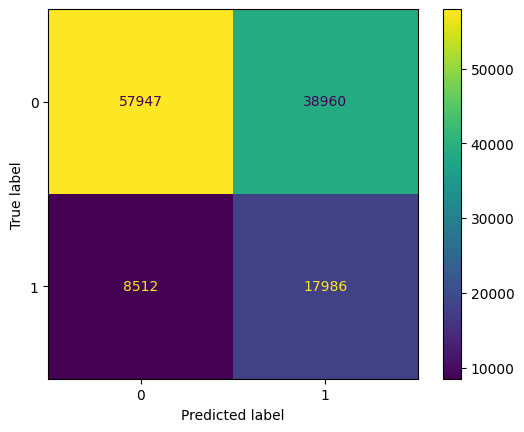

In [80]:
model = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth (start with 5-10)
    min_samples_split=100,    # Need at least 100 samples to split a node
    min_samples_leaf=50,      # Each leaf must have at least 50 samples
    max_features='sqrt',      # Only consider sqrt(n_features) at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=13, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", model)
        ]
    )

train(pipeline)

fit_time           29.413677
score_time          0.115485
test_f1             0.678440
train_f1            0.680977
test_precision      0.329918
train_precision     0.333294
test_recall         0.613479
train_recall        0.619764
test_f2             0.655297
train_f2            0.657938
dtype: float64


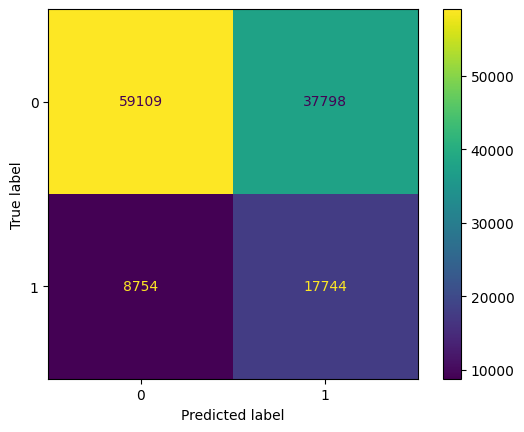

In [78]:
model = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth (start with 5-10)
    min_samples_split=100,    # Need at least 100 samples to split a node
    min_samples_leaf=50,      # Each leaf must have at least 50 samples
    max_features='sqrt',      # Only consider sqrt(n_features) at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=10, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", model)
        ]
    )

train(pipeline)

fit_time           29.505664
score_time          0.140800
test_f1             0.644425
train_f1            0.645090
test_precision      0.314736
train_precision     0.315503
test_recall         0.694015
train_recall        0.694930
test_f2             0.613156
train_f2            0.613883
dtype: float64


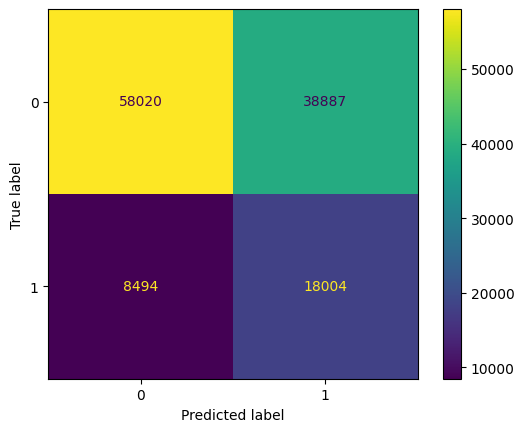

In [79]:
model = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth (start with 5-10)
    min_samples_split=100,    # Need at least 100 samples to split a node
    min_samples_leaf=50,      # Each leaf must have at least 50 samples
    max_features='sqrt',      # Only consider sqrt(n_features) at each split
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=7, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", model)
        ]
    )

train(pipeline)

## Random Forest 




In [82]:
from sklearn.ensemble import RandomForestClassifier

fit_time           55.517558
score_time          1.507047
test_f1             0.727796
train_f1            0.997583
test_precision      0.429547
train_precision     0.997746
test_recall         0.143896
train_recall        0.990990
test_f2             0.753059
train_f2            0.997588
dtype: float64


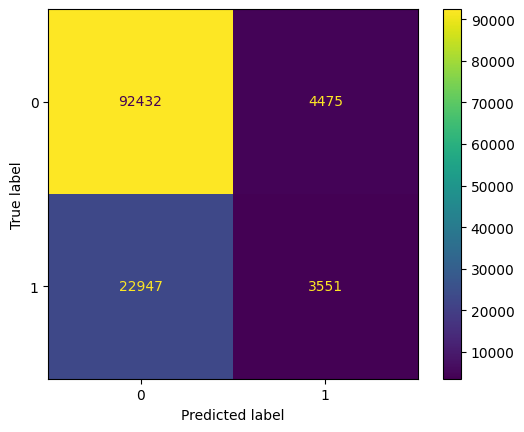

In [83]:
model = RandomForestClassifier()

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=7, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", model)
        ]
    )

train(pipeline)

fit_time           41.575881
score_time          0.372604
test_f1             0.689912
train_f1            0.706728
test_precision      0.345246
train_precision     0.368220
test_recall         0.642577
train_recall        0.685391
test_f2             0.667167
train_f2            0.684623
dtype: float64


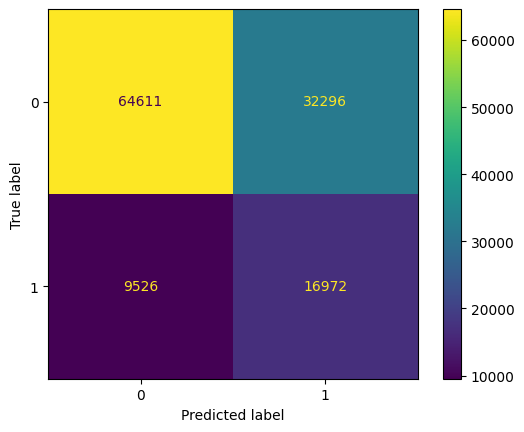

In [84]:
rf = RandomForestClassifier(
    n_estimators=100,         # Number of trees
    max_depth=10,             # Still constrain depth
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',      # Only use sqrt(n_features) per tree
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=10, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", rf)
        ]
    )

train(pipeline)

## XGBoost 


## LightGBM

## Catboost 

In [ ]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier()

pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor), 
            ("quasi-constant feature dropping", DropConstantFeatures(tol=0.95)),  
            ("mutual-information selector", MutualInfoSelector(k=10, categorical_indices=[45, 46, 47, 48, 49])), 
            ("model", cat)
        ]
    )

train(pipeline)